In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import math

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Flatten, Dropout

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Introducción a redes neuronales para problemas de regresión

In [2]:
# La raw URL del CSV en GitHub
url = 'https://raw.githubusercontent.com/EduardoSelimMM/2026PrimaveraUP_ML/refs/heads/main/sesion26/startups_data.csv'

# Se lee el CSV y se guarda en un pandas DataFrame
df = pd.read_csv(url)

In [3]:
df.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [4]:
# Ya saben nos gusta conocer las dimensiones de nuestro DataFrame
df.shape

(50, 5)

In [5]:
# Se aplica el método info()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     object 
 4   Profit           50 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.1+ KB


In [6]:
# Sin mucho análisis o justificación se quitarán los NAs
df = df.dropna()

In [7]:
# El tamaño de nuestro dataset
df.shape

(50, 5)

In [8]:
df.columns

Index(['R&D Spend', 'Administration', 'Marketing Spend', 'State', 'Profit'], dtype='object')

In [9]:
df.columns = ['research', 'administration', 'marketing', 'state', 'profit']

In [10]:
df.columns

Index(['research', 'administration', 'marketing', 'state', 'profit'], dtype='object')

In [11]:
df['state'].value_counts()

,count
state,
New York,17
California,17
Florida,16


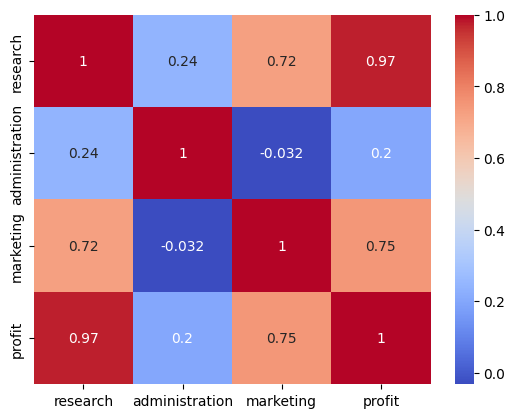

In [12]:
corr_matrix = df.corr(numeric_only = True)
sns.heatmap(corr_matrix, annot = True, cmap = 'coolwarm')
plt.show()

In [13]:
fig = px.histogram(df, x = "profit", color = "state", facet_col="state")
fig.show()

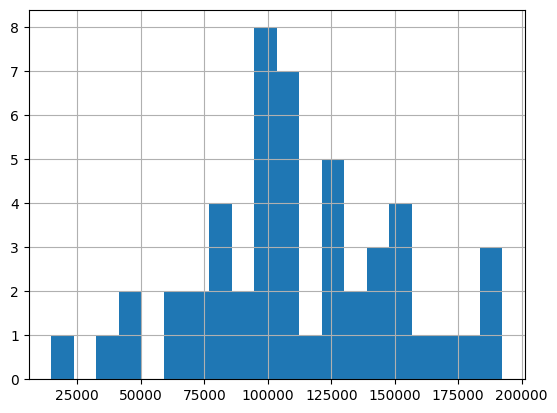

In [14]:
# Hagamos un histograma de la variable respuesta
df['profit'].hist(bins = 20)
plt.show()

In [15]:
# Se definen los grupos de variables explicativas
variables_numericas = ['research', 'administration', 'marketing']

variables_categoricas = ['state']

# Se define quienes serán tanto la variable objetivo, como las variables explicativas
y = df['profit']
X = df[variables_numericas + variables_categoricas]

# División de datos (entrenamiento y prueba)
# 20% como datos de prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 2026)

# Hay que preprocesar a la variables explicativas
# - Numéricas: Escalado
# - Categóricas: OneHotEncoding (convierte texto/categorías a 0s y 1s)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), variables_numericas),
        ('cat', OneHotEncoder(drop = 'first', handle_unknown = 'ignore'), variables_categoricas)
    ]
)

# Ajustar y transformar los datos de entrenamiento
X_train_processed = preprocessor.fit_transform(X_train)

# Transformar los datos de test (usando el ajuste de train)
X_test_processed = preprocessor.transform(X_test)

# El número de columnas resultantes después de la transformación
dim_input = X_train_processed.shape[1]

In [16]:
dim_input

5

In [17]:
model = Sequential([
    # Capa de entrada pura (solo define la forma de los datos de entrada)
    Input(shape=(dim_input,)),

    # Primera capa oculta
    Dense(8, activation = 'relu'),

    # Segunda capa oculta
    Dense(4, activation = 'relu'),

    # Capa de salida
    Dense(1, activation = 'linear') # IMPORTANTE: Para problemas de regresión
])

In [18]:
# Información básica del modelo
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 89 (356.00 B)

 Trainable params: 89 (356.00 B)

 Non-trainable params: 0 (0.00 B)

In [19]:
# Compilación del modelo
model.compile(optimizer = 'adam',
              loss = 'mean_squared_error',
              metrics = ['mse', 'mae', 'mape'])

# Entrenamiento del modelo
model.fit(X_train_processed, y_train, epochs = 50, batch_size = 5, verbose = 1)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 14631741440.0000 - mae: 113244.0234 - mape: 99.9997 - mse: 14631741440.0000
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 14631725056.0000 - mae: 113243.9609 - mape: 99.9997 - mse: 14631725056.0000 
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 14631708672.0000 - mae: 113243.8984 - mape: 99.9996 - mse: 14631708672.0000
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 14631693312.0000 - mae: 113243.8516 - mape: 99.9996 - mse: 14631695360.0000 
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 14631673856.0000 - mae: 113243.7734 - mape: 99.9995 - mse: 14631673856.0000 
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 14631655424.0000 - mae: 113243.7109 - mape: 99.9994 - mse: 14631655424.0000 
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 14631635968.0000 - mae: 113243.6406 - mape: 99.9994 - mse: 14631635968.0000 
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 14631611392.000

In [20]:
metricas_train = model.evaluate(X_train_processed, y_train)
loss_train, mse_train, mae_train, mape_train = metricas_train
rmse_train = math.sqrt(mse_train)

metricas_test = model.evaluate(X_test_processed, y_test)
loss_test, mse_test, mae_test, mape_test = metricas_test
rmse_test = math.sqrt(mse_test)

print(f"RMSE en Train: {rmse_train}")
print(f"MAE en Train: {mae_train}")

print(f"RMSE en Test: {rmse_test}")
print(f"MAE en Test: {mae_test}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 14626846720.0000 - mae: 113225.7109 - mape: 99.9833 - mse: 14626846720.0000 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 12163057664.0000 - mae: 107067.4219 - mape: 99.9833 - mse: 12163057664.0000
RMSE en Train: 120941.50123096703
MAE en Train: 113225.7109375
RMSE en Test: 110286.25328661774
MAE en Test: 107067.421875


# Otro dataset: Precio de autos

In [21]:
# La raw URL del CSV en GitHub
url = 'https://raw.githubusercontent.com/EduardoSelimMM/2026PrimaveraUP_ML/refs/heads/main/sesion26/cars_price.csv'

In [22]:
# Se lee el CSV y se guarda en un pandas DataFrame
df = pd.read_csv(url)

In [23]:
df.head()

,ID,symboling,name,fueltypes,aspiration,doornumbers,carbody,drivewheels,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [24]:
# Ya saben nos gusta conocer las dimensiones de nuestro DataFrame
df.shape

(205, 26)

In [25]:
# Se aplica el método info()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   name              205 non-null    object 
 3   fueltypes         205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumbers       205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheels       205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

In [26]:
# Sin mucho análisis o justificación se quitarán los NAs
df = df.dropna()

In [27]:
# El tamaño de nuestro dataset
df.shape

(205, 26)

In [28]:
df.columns

Index(['ID', 'symboling', 'name', 'fueltypes', 'aspiration', 'doornumbers',
       'carbody', 'drivewheels', 'enginelocation', 'wheelbase', 'carlength',
       'carwidth', 'carheight', 'curbweight', 'enginetype', 'cylindernumber',
       'enginesize', 'fuelsystem', 'boreratio', 'stroke', 'compressionratio',
       'horsepower', 'peakrpm', 'citympg', 'highwaympg', 'price'],
      dtype='object')

In [29]:
df['fueltypes'].value_counts()

,count
fueltypes,
gas,185
diesel,20


In [30]:
df['doornumbers'].value_counts()

,count
doornumbers,
four,115
two,90


In [31]:
df['cylindernumber'].value_counts()

,count
cylindernumber,
four,159
six,24
five,11
eight,5
two,4
twelve,1
three,1


In [32]:
mapeo = {
    'two': 2,
    'three': 3,
    'four': 4,
    'five': 5,
    'six': 6,
    'eight': 8,
    'twelve': 12
}

In [33]:
df['num_cilindros'] = df['cylindernumber'].map(mapeo)
df['num_puertas'] = df['doornumbers'].map(mapeo)

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 28 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   name              205 non-null    object 
 3   fueltypes         205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumbers       205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheels       205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

In [35]:
df.head()

,ID,symboling,name,fueltypes,aspiration,doornumbers,carbody,drivewheels,enginelocation,wheelbase,...,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,num_cilindros,num_puertas
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,3.47,2.68,9.0,111,5000,21,27,13495.0,4,2
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,3.47,2.68,9.0,111,5000,21,27,16500.0,4,2
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,2.68,3.47,9.0,154,5000,19,26,16500.0,6,2
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,3.19,3.40,10.0,102,5500,24,30,13950.0,4,4
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,3.19,3.40,8.0,115,5500,18,22,17450.0,5,4


In [36]:
df.columns

Index(['ID', 'symboling', 'name', 'fueltypes', 'aspiration', 'doornumbers',
       'carbody', 'drivewheels', 'enginelocation', 'wheelbase', 'carlength',
       'carwidth', 'carheight', 'curbweight', 'enginetype', 'cylindernumber',
       'enginesize', 'fuelsystem', 'boreratio', 'stroke', 'compressionratio',
       'horsepower', 'peakrpm', 'citympg', 'highwaympg', 'price',
       'num_cilindros', 'num_puertas'],
      dtype='object')

In [37]:
variables_categoricas = ['fueltypes', 'aspiration', 'carbody', 'drivewheels',
                         'enginelocation', 'enginetype', 'fuelsystem']
variables_numericas = ['num_puertas', 'num_cilindros', 'wheelbase', 'carlength', 'carwidth',
                       'carheight', 'curbweight', 'enginesize', 'boreratio', 'stroke',
                       'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg']

In [38]:
df[variables_categoricas].head()

,fueltypes,aspiration,carbody,drivewheels,enginelocation,enginetype,fuelsystem
0,gas,std,convertible,rwd,front,dohc,mpfi
1,gas,std,convertible,rwd,front,dohc,mpfi
2,gas,std,hatchback,rwd,front,ohcv,mpfi
3,gas,std,sedan,fwd,front,ohc,mpfi
4,gas,std,sedan,4wd,front,ohc,mpfi


In [39]:
df[variables_numericas].head()

,num_puertas,num_cilindros,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg
0,2,4,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,9.0,111,5000,21,27
1,2,4,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,9.0,111,5000,21,27
2,2,6,94.5,171.2,65.5,52.4,2823,152,2.68,3.47,9.0,154,5000,19,26
3,4,4,99.8,176.6,66.2,54.3,2337,109,3.19,3.40,10.0,102,5500,24,30
4,4,5,99.4,176.6,66.4,54.3,2824,136,3.19,3.40,8.0,115,5500,18,22


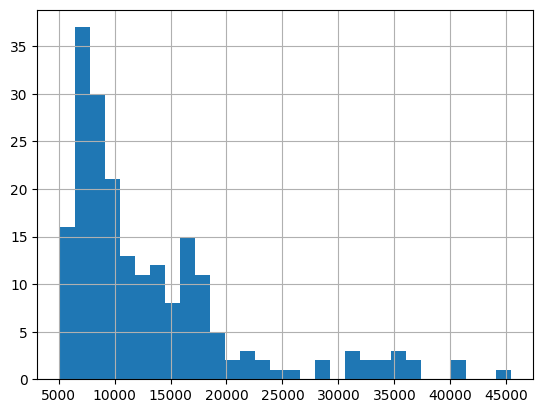

In [40]:
# Hagamos un histograma de la variable respuesta
df['price'].hist(bins = 30)
plt.show()

In [41]:
# Se define quienes serán tanto la variable objetivo, como las variables explicativas
y = df['price']
X = df[variables_numericas + variables_categoricas]

# División de datos (entrenamiento y prueba)
# 20% como datos de prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 2025)

# Hay que preprocesar a la variables explicativas
# - Numéricas: Escalado
# - Categóricas: OneHotEncoding (convierte texto/categorías a 0s y 1s)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), variables_numericas),
        ('cat', OneHotEncoder(drop = 'first', handle_unknown = 'ignore'), variables_categoricas)
    ]
)

# Ajustar y transformar los datos de entrenamiento
X_train_processed = preprocessor.fit_transform(X_train)

# Transformar los datos de test (usando el ajuste de train)
X_test_processed = preprocessor.transform(X_test)

# El número de columnas resultantes después de la transformación
dim_input = X_train_processed.shape[1]

In [42]:
dim_input

37

## Primer modelo

In [43]:
model_reg = Sequential([
    # Capa de entrada pura (solo define la forma de los datos de entrada)
    Input(shape=(dim_input,)),

    # Primera capa oculta
    Dense(8, activation = 'relu'),

    # Segunda capa oculta
    Dense(4, activation = 'relu'),

    # Capa de salida
    Dense(1, activation = 'linear') # IMPORTANTE: Para problemas de regresión
])

In [44]:
# Información básica del modelo
model_reg.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 8)              │           304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 345 (1.35 KB)

 Trainable params: 345 (1.35 KB)

 Non-trainable params: 0 (0.00 B)

In [45]:
# Compilación del modelo
model_reg.compile(optimizer = 'adam',
              loss = 'mean_squared_error',
              metrics = ['mse', 'mae', 'mape'])

# Entrenamiento del modelo
model_reg.fit(X_train_processed, y_train, epochs = 50, batch_size = 5, verbose = 1)

Epoch 1/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 236351584.0000 - mae: 13128.1006 - mape: 99.9991 - mse: 236351584.0000
Epoch 2/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 236345792.0000 - mae: 13127.9219 - mape: 99.9975 - mse: 236345792.0000
Epoch 3/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 236334624.0000 - mae: 13127.5713 - mape: 99.9945 - mse: 236334624.0000
Epoch 4/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 236314304.0000 - mae: 13126.9346 - mape: 99.9890 - mse: 236314304.0000
Epoch 5/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 236282832.0000 - mae: 13125.8936 - mape: 99.9796 - mse: 236282832.0000
Epoch 6/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 236235744.0000 - mae: 13124.4404 - mape: 99.9671 - mse: 236235744.0000
Epoch 7/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 236170960.0000 - mae: 13122.3428 - mape: 99.9489 - mse: 236170960.0000
Epoch 8/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 236081520.0000 - mae: 13119.4600 - mape

In [46]:
metricas_train = model_reg.evaluate(X_train_processed, y_train)
loss_train, mse_train, mae_train, mape_train = metricas_train
rmse_train = math.sqrt(mse_train)

metricas_test = model_reg.evaluate(X_test_processed, y_test)
loss_test, mse_test, mae_test, mape_test = metricas_test
rmse_test = math.sqrt(mse_test)

print(f"RMSE en Train: {rmse_train}")
print(f"MAE en Train: {mae_train}")

print(f"RMSE en Test: {rmse_test}")
print(f"MAE en Test: {mae_test}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 140496656.0000 - mae: 9980.3525 - mape: 76.0181 - mse: 140496656.0000  
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 146135600.0000 - mae: 10559.3936 - mape: 76.4952 - mse: 146135600.0000
RMSE en Train: 11853.128532163988
MAE en Train: 9980.3525390625
RMSE en Test: 12088.655839256902
MAE en Test: 10559.3935546875


## Otro modelo con uso de dropout

+ Durante el entrenamiento, el **dropout** "apaga" aleatoriamente un porcentaje de neuronas en cada iteración.

+ Esto evita la dependencia, pue las neuronas no pueden "confiar" en que una neurona vecina específica extraerá una característica.

+ Fomenta la redundancia, ya que "obliga" a todas las neuronas a aprender representaciones útiles de los datos.

+ Evita que la red memorice el ruido o detalles aleatorios de los datos de entrenamiento, obligándola a aprender patrones más generales, i.e. combate el overfitting

+ En el entrenamiento, la red es "perezosa" y tiende a que unas pocas neuronas hagan todo el trabajo (especialización excesiva). El dropout rompe esas alianzas forzando a la red a ser robusta.

+ En la prueba, el dropout se apaga. Todas las neuronas trabajan juntas, pero ahora cada una es mucho más capaz y autónoma porque "entrenaron bajo presión".

+ Sin dropout, las redes neuronales grandes suelen aprenderse los datos de memoria (overfitting). Con dropout, el modelo generaliza mucho mejor, lo que significa que funcionará mejor con datos nuevos que nunca ha visto.

+ Se dice que es una técnica de supervivencia para neuronas: "Aprende a trabajar tú sola, porque mañana podrías no tener a tu compañera al lado".

+ El dropout obliga a la red a tratar de encontrar una solución al problema usando un subconjunto diferente de parámetros en cada iteración.

+ El dropout es una técnica de regularización que modifica la arquitectura de la red en cada iteración del entrenamiento.

+ Reduce la co-adaptación de neuronas, i.e. evita que una neurona dependa de la presencia de otra neurona específica para corregir sus errores. Al ser el entorno ruidoso, cada neurona debe ser útil de forma más independiente.

+ Se dice que es una aproximación a un "ensemble". Entrenar con dropout es equivalente a entrenar miles de arquitecturas pequeñas y diferentes al mismo tiempo. Al finalizar, el modelo sin dropout actúa como un promedio de todos esos modelos, lo que reduce drásticamente la varianza del error.

In [47]:
model_con_dropout = Sequential([
    # Capa de entrada pura (solo define la forma de los datos de entrada)
    Input(shape=(dim_input,)),

    # Primera capa oculta
    Dense(128, activation = 'relu'),
    Dropout(0.2),

    # Segunda capa oculta
    Dense(256, activation = 'relu'),
    Dropout(0.3),

    # Tercera capa oculta
    Dense(32, activation = 'relu'),
    Dropout(0.1),

    # Capa de salida
    Dense(1, activation = 'linear') # IMPORTANTE: Para problemas de regresión
])

In [48]:
# Información básica del modelo
model_con_dropout.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,145 (180.25 KB)

 Trainable params: 46,145 (180.25 KB)

 Non-trainable params: 0 (0.00 B)

In [49]:
# Compilación del modelo
model_con_dropout.compile(optimizer = 'adam',
              loss = 'mean_squared_error',
              metrics = ['mse', 'mae', 'mape'])

# Entrenamiento del modelo
model_con_dropout.fit(X_train_processed, y_train, epochs = 50, batch_size = 5, verbose = 1)

Epoch 1/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 236157008.0000 - mae: 13121.5762 - mape: 99.9383 - mse: 236157008.0000
Epoch 2/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 233661008.0000 - mae: 13038.0225 - mape: 99.1777 - mse: 233661008.0000
Epoch 3/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 216504912.0000 - mae: 12454.6279 - mape: 93.9090 - mse: 216504912.0000
Epoch 4/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 157027536.0000 - mae: 10170.2275 - mape: 74.4232 - mse: 157027536.0000
Epoch 5/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 58809712.0000 - mae: 5140.9834 - mape: 34.5860 - mse: 58809712.0000
Epoch 6/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 18334250.0000 - mae: 2889.3086 - mape: 22.2300 - mse: 18334250.0000
Epoch 7/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 17146482.0000 - mae: 2797.3503 - mape: 20.5013 - mse: 17146482.0000
Epoch 8/50
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 14144308.0000 - mae: 2513.0933 - mape: 18.5174 -

In [50]:
metricas_train = model_con_dropout.evaluate(X_train_processed, y_train)
loss_train, mse_train, mae_train, mape_train = metricas_train
rmse_train = math.sqrt(mse_train)

metricas_test = model_con_dropout.evaluate(X_test_processed, y_test)
loss_test, mse_test, mae_test, mape_test = metricas_test
rmse_test = math.sqrt(mse_test)

print(f"RMSE en Train: {rmse_train}")
print(f"MAE en Train: {mae_train}")

print(f"RMSE en Test: {rmse_test}")
print(f"MAE en Test: {mae_test}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 3854333.2500 - mae: 1445.4602 - mape: 11.8478 - mse: 3854333.2500  
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 13528982.0000 - mae: 2088.0820 - mape: 12.9304 - mse: 13528982.0000
RMSE en Train: 1963.2455908520462
MAE en Train: 1445.460205078125
RMSE en Test: 3678.176450362326
MAE en Test: 2088.08203125
